In [1]:
pip install mordred rdkit

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Source — BindingDB

Compound bioactivity data was sourced from **BindingDB** rather than 
ChEMBL, which is the more commonly used database for this type of project.

ChEMBL was the original intended data source, however its API was 
returning persistent HTTP 500 errors at the time of this project. 
BindingDB was selected as an alternative because:

- It is a peer-reviewed, publicly accessible database of measured 
  binding affinities
- It contains high-quality IC50, Ki, and Kd data for drug targets
- It uses a similar data structure to ChEMBL, making the pipeline 
  easily transferable
- EGFR is well-represented in BindingDB with curated experimental data

The pipeline is designed to work with ChEMBL data with minimal 
modification once the API is restored.

In [3]:
df = pd.read_csv("EGFR Targets.tsv", sep = '\t')
df

,BindingDB Reactant_set_id,Ligand SMILES,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (SwissProt) Recommended Name of Target Chain 50,UniProt (SwissProt) Entry Name of Target Chain 50,UniProt (SwissProt) Primary ID of Target Chain 50,UniProt (SwissProt) Secondary ID(s) of Target Chain 50,UniProt (SwissProt) Alternative ID(s) of Target Chain 50,UniProt (TrEMBL) Submitted Name of Target Chain 50,UniProt (TrEMBL) Entry Name of Target Chain 50,UniProt (TrEMBL) Primary ID of Target Chain 50,UniProt (TrEMBL) Secondary ID(s) of Target Chain 50,UniProt (TrEMBL) Alternative ID(s) of Target Chain 50
0,51382967,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,InChI=1S/C28H33N7O2/c1-7-27(36)30-22-16-23(26(...,DUYJMQONPNNFPI-UHFFFAOYSA-N,50029668,"AZD-9291::Osimertinib::US10085983, Compound AZ...",Epidermal growth factor receptor,Homo sapiens,NaN,0.002000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5347,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,InChI=1S/C18H12BrN3/c19-14-6-3-7-15(10-14)22-1...,BUVKJPOCMOXSSQ-UHFFFAOYSA-N,3585,4-[(3-Bromophenyl)amino]benzo[g]quinazoline::N...,Epidermal growth factor receptor,Homo sapiens,NaN,0.003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5318,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,InChI=1S/C18H18BrN3O2/c1-3-23-16-9-14-15(10-17...,YXOXHAUUTIOBDA-UHFFFAOYSA-N,3556,"PD153035 Analog::4-[(3-Bromophenyl)amino]-6,7-...",Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5366,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,InChI=1S/C15H14BrN5/c1-21(2)14-7-12-13(8-17-14...,QFXMHNZCUIIRHD-UHFFFAOYSA-N,3604,CHEMBL53711::4-[(3-bromophenyl)-amino]-6-(dime...,Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5462,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,InChI=1S/C15H14BrN5/c1-21(2)14-7-12-13(8-17-14...,QFXMHNZCUIIRHD-UHFFFAOYSA-N,3604,CHEMBL53711::4-[(3-bromophenyl)-amino]-6-(dime...,Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,51537952,COc1cc(N2CCC(CC2)N2CC(C)(CO)C2)c(C)cc1Nc1ncc(B...,InChI=1S/C32H40BrN8O3P/c1-20-14-25(27(44-3)15-...,NMSJKIAOJNJHER-UHFFFAOYSA-N,50618654,CHEMBL5393923,Epidermal growth factor receptor,Homo sapiens,NaN,0.060000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245,51468677,COc1cc(N2CCC(CC2)N2CC(C2)N(C)C)c(C)cc1Nc1ncc(B...,InChI=1S/C32H41BrN9O2P/c1-20-15-26(28(44-4)16-...,FQRDFGLNAOZTSA-UHFFFAOYSA-N,50592743,CHEMBL5186680,Epidermal growth factor receptor,Homo sapiens,NaN,0.060000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246,1580206,Cc1c2c(nn1CCN1CCN(C)CC1)CN(C)C[C@H](C)Oc1c(cnn...,NaN,NaN,789987,"(10S,17E)-8,10,12,16-tetramethyl-15-[2- (4-met...","Epidermal growth factor receptor [T790M,L858R]",Homo sapiens,NaN,0.060,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
247,51537956,COc1cc(N2CCC(CC2)N(C)CCN(C)C)c(C)cc1Nc1ncc(Br)...,InChI=1S/C32H43BrN9O2P/c1-21-18-26(28(44-5)19-...,XQCZHAJCRYMQIL-UHFFFAOYSA-N,50618659,CHEMBL5436031,Epidermal growth factor receptor,Homo sapiens,NaN,0.060000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.head()

,BindingDB Reactant_set_id,Ligand SMILES,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (SwissProt) Recommended Name of Target Chain 50,UniProt (SwissProt) Entry Name of Target Chain 50,UniProt (SwissProt) Primary ID of Target Chain 50,UniProt (SwissProt) Secondary ID(s) of Target Chain 50,UniProt (SwissProt) Alternative ID(s) of Target Chain 50,UniProt (TrEMBL) Submitted Name of Target Chain 50,UniProt (TrEMBL) Entry Name of Target Chain 50,UniProt (TrEMBL) Primary ID of Target Chain 50,UniProt (TrEMBL) Secondary ID(s) of Target Chain 50,UniProt (TrEMBL) Alternative ID(s) of Target Chain 50
0,51382967,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,InChI=1S/C28H33N7O2/c1-7-27(36)30-22-16-23(26(...,DUYJMQONPNNFPI-UHFFFAOYSA-N,50029668,"AZD-9291::Osimertinib::US10085983, Compound AZ...",Epidermal growth factor receptor,Homo sapiens,NaN,0.002000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5347,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,InChI=1S/C18H12BrN3/c19-14-6-3-7-15(10-14)22-1...,BUVKJPOCMOXSSQ-UHFFFAOYSA-N,3585,4-[(3-Bromophenyl)amino]benzo[g]quinazoline::N...,Epidermal growth factor receptor,Homo sapiens,NaN,0.003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5318,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,InChI=1S/C18H18BrN3O2/c1-3-23-16-9-14-15(10-17...,YXOXHAUUTIOBDA-UHFFFAOYSA-N,3556,"PD153035 Analog::4-[(3-Bromophenyl)amino]-6,7-...",Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5366,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,InChI=1S/C15H14BrN5/c1-21(2)14-7-12-13(8-17-14...,QFXMHNZCUIIRHD-UHFFFAOYSA-N,3604,CHEMBL53711::4-[(3-bromophenyl)-amino]-6-(dime...,Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5462,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,InChI=1S/C15H14BrN5/c1-21(2)14-7-12-13(8-17-14...,QFXMHNZCUIIRHD-UHFFFAOYSA-N,3604,CHEMBL53711::4-[(3-bromophenyl)-amino]-6-(dime...,Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns

Index(['BindingDB Reactant_set_id', 'Ligand SMILES', 'Ligand InChI',
       'Ligand InChI Key', 'BindingDB MonomerID', 'BindingDB Ligand Name',
       'Target Name',
       'Target Source Organism According to Curator or DataSource', 'Ki (nM)',
       'IC50 (nM)',
       ...
       'UniProt (SwissProt) Recommended Name of Target Chain 50',
       'UniProt (SwissProt) Entry Name of Target Chain 50',
       'UniProt (SwissProt) Primary ID of Target Chain 50',
       'UniProt (SwissProt) Secondary ID(s) of Target Chain 50',
       'UniProt (SwissProt) Alternative ID(s) of Target Chain 50',
       'UniProt (TrEMBL) Submitted Name of Target Chain 50',
       'UniProt (TrEMBL) Entry Name of Target Chain 50',
       'UniProt (TrEMBL) Primary ID of Target Chain 50',
       'UniProt (TrEMBL) Secondary ID(s) of Target Chain 50',
       'UniProt (TrEMBL) Alternative ID(s) of Target Chain 50'],
      dtype='object', length=640)

In [6]:
df.shape

(249, 640)

In [7]:
df.to_csv('bioactivity_data.csv', index= False)

## Handling Missing Data ## 

In [8]:
df2 = df.dropna(subset = ['IC50 (nM)'])
df2

,BindingDB Reactant_set_id,Ligand SMILES,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (SwissProt) Recommended Name of Target Chain 50,UniProt (SwissProt) Entry Name of Target Chain 50,UniProt (SwissProt) Primary ID of Target Chain 50,UniProt (SwissProt) Secondary ID(s) of Target Chain 50,UniProt (SwissProt) Alternative ID(s) of Target Chain 50,UniProt (TrEMBL) Submitted Name of Target Chain 50,UniProt (TrEMBL) Entry Name of Target Chain 50,UniProt (TrEMBL) Primary ID of Target Chain 50,UniProt (TrEMBL) Secondary ID(s) of Target Chain 50,UniProt (TrEMBL) Alternative ID(s) of Target Chain 50
0,51382967,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,InChI=1S/C28H33N7O2/c1-7-27(36)30-22-16-23(26(...,DUYJMQONPNNFPI-UHFFFAOYSA-N,50029668,"AZD-9291::Osimertinib::US10085983, Compound AZ...",Epidermal growth factor receptor,Homo sapiens,NaN,0.002000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5347,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,InChI=1S/C18H12BrN3/c19-14-6-3-7-15(10-14)22-1...,BUVKJPOCMOXSSQ-UHFFFAOYSA-N,3585,4-[(3-Bromophenyl)amino]benzo[g]quinazoline::N...,Epidermal growth factor receptor,Homo sapiens,NaN,0.003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5318,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,InChI=1S/C18H18BrN3O2/c1-3-23-16-9-14-15(10-17...,YXOXHAUUTIOBDA-UHFFFAOYSA-N,3556,"PD153035 Analog::4-[(3-Bromophenyl)amino]-6,7-...",Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5366,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,InChI=1S/C15H14BrN5/c1-21(2)14-7-12-13(8-17-14...,QFXMHNZCUIIRHD-UHFFFAOYSA-N,3604,CHEMBL53711::4-[(3-bromophenyl)-amino]-6-(dime...,Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5462,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,InChI=1S/C15H14BrN5/c1-21(2)14-7-12-13(8-17-14...,QFXMHNZCUIIRHD-UHFFFAOYSA-N,3604,CHEMBL53711::4-[(3-bromophenyl)-amino]-6-(dime...,Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,51537952,COc1cc(N2CCC(CC2)N2CC(C)(CO)C2)c(C)cc1Nc1ncc(B...,InChI=1S/C32H40BrN8O3P/c1-20-14-25(27(44-3)15-...,NMSJKIAOJNJHER-UHFFFAOYSA-N,50618654,CHEMBL5393923,Epidermal growth factor receptor,Homo sapiens,NaN,0.060000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245,51468677,COc1cc(N2CCC(CC2)N2CC(C2)N(C)C)c(C)cc1Nc1ncc(B...,InChI=1S/C32H41BrN9O2P/c1-20-15-26(28(44-4)16-...,FQRDFGLNAOZTSA-UHFFFAOYSA-N,50592743,CHEMBL5186680,Epidermal growth factor receptor,Homo sapiens,NaN,0.060000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246,1580206,Cc1c2c(nn1CCN1CCN(C)CC1)CN(C)C[C@H](C)Oc1c(cnn...,NaN,NaN,789987,"(10S,17E)-8,10,12,16-tetramethyl-15-[2- (4-met...","Epidermal growth factor receptor [T790M,L858R]",Homo sapiens,NaN,0.060,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
247,51537956,COc1cc(N2CCC(CC2)N(C)CCN(C)C)c(C)cc1Nc1ncc(Br)...,InChI=1S/C32H43BrN9O2P/c1-21-18-26(28(44-5)19-...,XQCZHAJCRYMQIL-UHFFFAOYSA-N,50618659,CHEMBL5436031,Epidermal growth factor receptor,Homo sapiens,NaN,0.060000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
type(df2)

pandas.core.frame.DataFrame

In [10]:
df2['IC50 (nM)'] = pd.to_numeric (df2['IC50 (nM)'], errors = 'coerce')

/var/folders/kn/_2yfsq_10m972b_s7wq7ns_00000gn/T/ipykernel_34054/3351759068.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['IC50 (nM)'] = pd.to_numeric (df2['IC50 (nM)'], errors = 'coerce')


In [11]:
def classify(value):
    if value < 1000:
        return 'Active'
    elif value > 10000:
        return 'Inactive'
    else: return 'Intermediate'
        
df2['bioactivity_class'] = df2['IC50 (nM)'].apply(classify)

/var/folders/kn/_2yfsq_10m972b_s7wq7ns_00000gn/T/ipykernel_34054/372367872.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['bioactivity_class'] = df2['IC50 (nM)'].apply(classify)


In [12]:
df2

,BindingDB Reactant_set_id,Ligand SMILES,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (SwissProt) Entry Name of Target Chain 50,UniProt (SwissProt) Primary ID of Target Chain 50,UniProt (SwissProt) Secondary ID(s) of Target Chain 50,UniProt (SwissProt) Alternative ID(s) of Target Chain 50,UniProt (TrEMBL) Submitted Name of Target Chain 50,UniProt (TrEMBL) Entry Name of Target Chain 50,UniProt (TrEMBL) Primary ID of Target Chain 50,UniProt (TrEMBL) Secondary ID(s) of Target Chain 50,UniProt (TrEMBL) Alternative ID(s) of Target Chain 50,bioactivity_class
0,51382967,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,InChI=1S/C28H33N7O2/c1-7-27(36)30-22-16-23(26(...,DUYJMQONPNNFPI-UHFFFAOYSA-N,50029668,"AZD-9291::Osimertinib::US10085983, Compound AZ...",Epidermal growth factor receptor,Homo sapiens,NaN,0.002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active
1,5347,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,InChI=1S/C18H12BrN3/c19-14-6-3-7-15(10-14)22-1...,BUVKJPOCMOXSSQ-UHFFFAOYSA-N,3585,4-[(3-Bromophenyl)amino]benzo[g]quinazoline::N...,Epidermal growth factor receptor,Homo sapiens,NaN,0.003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active
2,5318,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,InChI=1S/C18H18BrN3O2/c1-3-23-16-9-14-15(10-17...,YXOXHAUUTIOBDA-UHFFFAOYSA-N,3556,"PD153035 Analog::4-[(3-Bromophenyl)amino]-6,7-...",Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active
3,5366,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,InChI=1S/C15H14BrN5/c1-21(2)14-7-12-13(8-17-14...,QFXMHNZCUIIRHD-UHFFFAOYSA-N,3604,CHEMBL53711::4-[(3-bromophenyl)-amino]-6-(dime...,Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active
4,5462,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,InChI=1S/C15H14BrN5/c1-21(2)14-7-12-13(8-17-14...,QFXMHNZCUIIRHD-UHFFFAOYSA-N,3604,CHEMBL53711::4-[(3-bromophenyl)-amino]-6-(dime...,Epidermal growth factor receptor,Homo sapiens,NaN,0.006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,51537952,COc1cc(N2CCC(CC2)N2CC(C)(CO)C2)c(C)cc1Nc1ncc(B...,InChI=1S/C32H40BrN8O3P/c1-20-14-25(27(44-3)15-...,NMSJKIAOJNJHER-UHFFFAOYSA-N,50618654,CHEMBL5393923,Epidermal growth factor receptor,Homo sapiens,NaN,0.060,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active
245,51468677,COc1cc(N2CCC(CC2)N2CC(C2)N(C)C)c(C)cc1Nc1ncc(B...,InChI=1S/C32H41BrN9O2P/c1-20-15-26(28(44-4)16-...,FQRDFGLNAOZTSA-UHFFFAOYSA-N,50592743,CHEMBL5186680,Epidermal growth factor receptor,Homo sapiens,NaN,0.060,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active
246,1580206,Cc1c2c(nn1CCN1CCN(C)CC1)CN(C)C[C@H](C)Oc1c(cnn...,NaN,NaN,789987,"(10S,17E)-8,10,12,16-tetramethyl-15-[2- (4-met...","Epidermal growth factor receptor [T790M,L858R]",Homo sapiens,NaN,0.060,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active
247,51537956,COc1cc(N2CCC(CC2)N(C)CCN(C)C)c(C)cc1Nc1ncc(Br)...,InChI=1S/C32H43BrN9O2P/c1-21-18-26(28(44-5)19-...,XQCZHAJCRYMQIL-UHFFFAOYSA-N,50618659,CHEMBL5436031,Epidermal growth factor receptor,Homo sapiens,NaN,0.060,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active


In [13]:
selection = ['BindingDB Reactant_set_id', 'Ligand SMILES', 'IC50 (nM)','bioactivity_class']
df3 = df2[selection]
df3

,BindingDB Reactant_set_id,Ligand SMILES,IC50 (nM),bioactivity_class
0,51382967,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,0.002,Active
1,5347,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,0.003,Active
2,5318,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,0.006,Active
3,5366,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.006,Active
4,5462,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.006,Active
...,...,...,...,...
244,51537952,COc1cc(N2CCC(CC2)N2CC(C)(CO)C2)c(C)cc1Nc1ncc(B...,0.060,Active
245,51468677,COc1cc(N2CCC(CC2)N2CC(C2)N(C)C)c(C)cc1Nc1ncc(B...,0.060,Active
246,1580206,Cc1c2c(nn1CCN1CCN(C)CC1)CN(C)C[C@H](C)Oc1c(cnn...,0.060,Active
247,51537956,COc1cc(N2CCC(CC2)N(C)CCN(C)C)c(C)cc1Nc1ncc(Br)...,0.060,Active


In [14]:
df3= df3.dropna(subset= ['BindingDB Reactant_set_id', 'Ligand SMILES', 'IC50 (nM)'])

In [15]:
df3.to_csv('bioactivity_preprocessed_data.csv', index = False)

## Calculate Lipinski Descriptors ##

Christopher Lipinski, a scientist at Pfizer, came up with a set of rules of thumb for evaluating the druglikeness of compounds. Drug likeliness is based on Absorption, Distribution, Metabolism, and Excretion (ADME), which is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the Rule-of-Five or Lipinski Rule.

The Lipinski's Rule stated the following:

Molecular Weight < 500 Dalton

Octanol-water partition coefficient (LogP) < 5

HBD < 5

HBA < 10

In [16]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [17]:
def lipinski(smiles, verbose=False):

    rows = []

    for elem in smiles:
        mol = Chem.MolFromSmiles(elem)
        if mol is not None:
            rows.append([
                Descriptors.MolWt(mol),
                Descriptors.MolLogP(mol),
                Lipinski.NumHDonors(mol),
                Lipinski.NumHAcceptors(mol)
            ])

    descriptors = pd.DataFrame(
        rows,
        columns=["MW", "LogP", "NumHDonors", "NumHAcceptors"]
    )

    return descriptors

In [18]:
df_lipinski= lipinski(df['Ligand SMILES'])

In [19]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,499.619,4.50980,2,7
1,350.219,5.28910,1,3
2,388.265,4.93330,1,5
3,344.216,3.59690,1,5
4,344.216,3.59690,1,5
...,...,...,...,...
244,695.603,5.51752,3,11
245,694.619,5.44912,2,11
246,529.693,3.09882,1,7
247,696.635,5.69672,2,11


In [20]:
df_combined = pd.concat([df3,df_lipinski], axis= 1)

In [21]:
df_combined

,BindingDB Reactant_set_id,Ligand SMILES,IC50 (nM),bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors
0,51382967.0,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,0.002,Active,499.619,4.50980,2,7
1,5347.0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,0.003,Active,350.219,5.28910,1,3
2,5318.0,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,0.006,Active,388.265,4.93330,1,5
3,5366.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.006,Active,344.216,3.59690,1,5
4,5462.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.006,Active,344.216,3.59690,1,5
...,...,...,...,...,...,...,...,...
89,NaN,NaN,NaN,NaN,506.365,5.24890,1,7
90,NaN,NaN,NaN,NaN,445.882,4.06130,1,7
193,NaN,NaN,NaN,NaN,511.552,5.24900,3,7
221,NaN,NaN,NaN,NaN,467.475,3.01690,1,10


In [22]:
df_combined= df_combined.dropna()

In [23]:
df_combined

,BindingDB Reactant_set_id,Ligand SMILES,IC50 (nM),bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors
0,51382967.0,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,0.002,Active,499.619,4.50980,2,7
1,5347.0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,0.003,Active,350.219,5.28910,1,3
2,5318.0,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,0.006,Active,388.265,4.93330,1,5
3,5366.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.006,Active,344.216,3.59690,1,5
4,5462.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.006,Active,344.216,3.59690,1,5
...,...,...,...,...,...,...,...,...
244,51537952.0,COc1cc(N2CCC(CC2)N2CC(C)(CO)C2)c(C)cc1Nc1ncc(B...,0.060,Active,695.603,5.51752,3,11
245,51468677.0,COc1cc(N2CCC(CC2)N2CC(C2)N(C)C)c(C)cc1Nc1ncc(B...,0.060,Active,694.619,5.44912,2,11
246,1580206.0,Cc1c2c(nn1CCN1CCN(C)CC1)CN(C)C[C@H](C)Oc1c(cnn...,0.060,Active,529.693,3.09882,1,7
247,51537956.0,COc1cc(N2CCC(CC2)N(C)CCN(C)C)c(C)cc1Nc1ncc(Br)...,0.060,Active,696.635,5.69672,2,11


## Convert IC50 to pIC50 ##

To allow IC50 data to be more uniformly distributed, we will convert IC50 to the negative logarithmic scale which is essentially -log10(IC50).

This custom function pIC50() will accept a DataFrame as input and will:

Take the IC50 values from the standard_value column and converts it from nM to M by multiplying the value by 10
Take the molar value and apply -log10
Delete the standard_value column and create a new pIC50 column

In [24]:
def pIC50(input):
    pIC50 = []

    for i in input['IC50 (nM)_norm']:
        molar = i*(10**-9)
        pIC50.append (-np.log10(molar))

    input['pIC50']= pIC50
    x = input.drop('IC50 (nM)_norm', axis = 1)

    return x

Note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise, the negative logarithmic value will become negative.

In [25]:
df_combined['IC50 (nM)'].describe()

count    240.000000
mean       0.024513
std        0.015764
min        0.002000
25%        0.012000
50%        0.020000
75%        0.031000
max        0.060000
Name: IC50 (nM), dtype: float64

In [26]:
-np.log10( (10**-9)* 100000000)

1.0

In [27]:
-np.log10( (10**-9)* 1000000000)

-0.0

In [28]:

def norm_value(input):
    norm = []

    for i in input['IC50 (nM)']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['IC50 (nM)_norm'] = norm
    x = input.drop('IC50 (nM)', axis = 1)
        
    return x


In [29]:
df_norm = norm_value(df_combined)
df_norm

/var/folders/kn/_2yfsq_10m972b_s7wq7ns_00000gn/T/ipykernel_34054/406751158.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input['IC50 (nM)_norm'] = norm


,BindingDB Reactant_set_id,Ligand SMILES,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,IC50 (nM)_norm
0,51382967.0,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,Active,499.619,4.50980,2,7,0.002
1,5347.0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,Active,350.219,5.28910,1,3,0.003
2,5318.0,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,Active,388.265,4.93330,1,5,0.006
3,5366.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,Active,344.216,3.59690,1,5,0.006
4,5462.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,Active,344.216,3.59690,1,5,0.006
...,...,...,...,...,...,...,...,...
244,51537952.0,COc1cc(N2CCC(CC2)N2CC(C)(CO)C2)c(C)cc1Nc1ncc(B...,Active,695.603,5.51752,3,11,0.060
245,51468677.0,COc1cc(N2CCC(CC2)N2CC(C2)N(C)C)c(C)cc1Nc1ncc(B...,Active,694.619,5.44912,2,11,0.060
246,1580206.0,Cc1c2c(nn1CCN1CCN(C)CC1)CN(C)C[C@H](C)Oc1c(cnn...,Active,529.693,3.09882,1,7,0.060
247,51537956.0,COc1cc(N2CCC(CC2)N(C)CCN(C)C)c(C)cc1Nc1ncc(Br)...,Active,696.635,5.69672,2,11,0.060


In [30]:
df_final = pIC50(df_norm)
df_final

,BindingDB Reactant_set_id,Ligand SMILES,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,51382967.0,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,Active,499.619,4.50980,2,7,11.698970
1,5347.0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,Active,350.219,5.28910,1,3,11.522879
2,5318.0,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,Active,388.265,4.93330,1,5,11.221849
3,5366.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,Active,344.216,3.59690,1,5,11.221849
4,5462.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,Active,344.216,3.59690,1,5,11.221849
...,...,...,...,...,...,...,...,...
244,51537952.0,COc1cc(N2CCC(CC2)N2CC(C)(CO)C2)c(C)cc1Nc1ncc(B...,Active,695.603,5.51752,3,11,10.221849
245,51468677.0,COc1cc(N2CCC(CC2)N2CC(C2)N(C)C)c(C)cc1Nc1ncc(B...,Active,694.619,5.44912,2,11,10.221849
246,1580206.0,Cc1c2c(nn1CCN1CCN(C)CC1)CN(C)C[C@H](C)Oc1c(cnn...,Active,529.693,3.09882,1,7,10.221849
247,51537956.0,COc1cc(N2CCC(CC2)N(C)CCN(C)C)c(C)cc1Nc1ncc(Br)...,Active,696.635,5.69672,2,11,10.221849


In [31]:
df_final.pIC50.describe()

count    240.000000
mean      10.704593
std        0.299371
min       10.221849
25%       10.508638
50%       10.698970
75%       10.920819
max       11.698970
Name: pIC50, dtype: float64

In [32]:
df_final['class'] = pd.qcut(df_final['pIC50'], q=3, labels=['low','medium','high'])

In [33]:
df_final

,BindingDB Reactant_set_id,Ligand SMILES,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50,class
0,51382967.0,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,Active,499.619,4.50980,2,7,11.698970,high
1,5347.0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,Active,350.219,5.28910,1,3,11.522879,high
2,5318.0,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,Active,388.265,4.93330,1,5,11.221849,high
3,5366.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,Active,344.216,3.59690,1,5,11.221849,high
4,5462.0,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,Active,344.216,3.59690,1,5,11.221849,high
...,...,...,...,...,...,...,...,...,...
244,51537952.0,COc1cc(N2CCC(CC2)N2CC(C)(CO)C2)c(C)cc1Nc1ncc(B...,Active,695.603,5.51752,3,11,10.221849,low
245,51468677.0,COc1cc(N2CCC(CC2)N2CC(C2)N(C)C)c(C)cc1Nc1ncc(B...,Active,694.619,5.44912,2,11,10.221849,low
246,1580206.0,Cc1c2c(nn1CCN1CCN(C)CC1)CN(C)C[C@H](C)Oc1c(cnn...,Active,529.693,3.09882,1,7,10.221849,low
247,51537956.0,COc1cc(N2CCC(CC2)N(C)CCN(C)C)c(C)cc1Nc1ncc(Br)...,Active,696.635,5.69672,2,11,10.221849,low


## Exploratory Data Analysis ##

### Note on Bioactivity Distribution

The dataset used in this study contains compounds with very high potency, as indicated by pIC50 values predominantly in the range of 10–11. This corresponds to sub-nanomolar IC50 values, suggesting that the dataset is biased toward highly active compounds.

As a result, standard bioactivity classification thresholds (e.g., active/inactive based on pIC50 values of 7 and 5) were not suitable, since all compounds would be classified as active.

To address this, relative classification based on the distribution of pIC50 values was used. Compounds were grouped into categories such as low, medium, and high activity using percentile-based binning. This approach allows meaningful comparative analysis within the dataset despite its high potency bias.


In [34]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

## Frequency plot of the 3 bioactivity classes ##

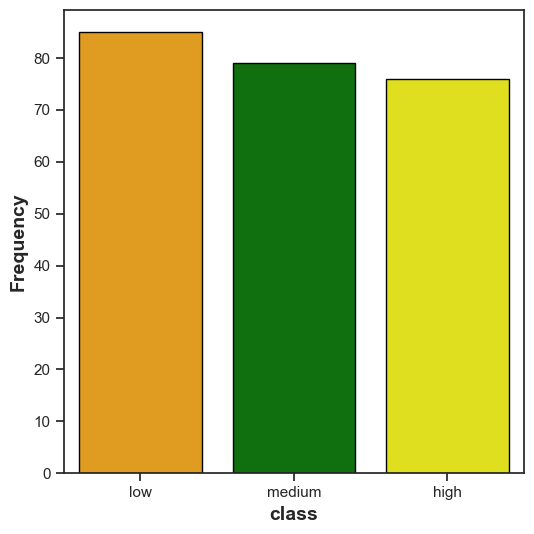

In [35]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_final, edgecolor='black', hue='class', palette= ['orange', 'green', 'yellow'])

plt.xlabel('class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_class.pdf')

## Scatter plot of MW versus LogP ##

It can be seen that the 2 bioactivity classes span similar chemical spaces as evident by the scatter plot of MW vs LogP.

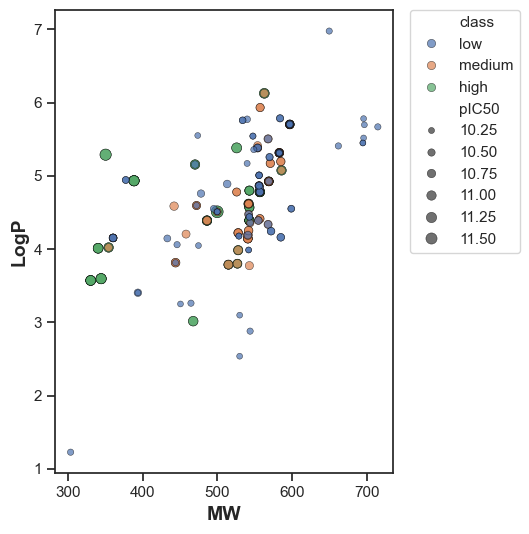

In [36]:

plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_final, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

plt.tight_layout()
plt.savefig('plot_MW_vs_LogP.pdf')


## Box plots ##
### pIC50 value ###

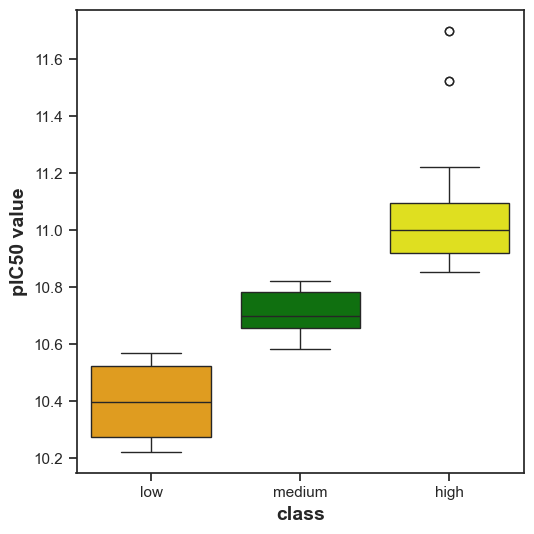

In [37]:

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_final, hue='class', palette= ['orange', 'green', 'yellow'])

plt.xlabel('class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_ic50.pdf')

In [38]:
def mannwhitney(descriptor):
    from scipy.stats import mannwhitneyu

    df = df_final[[descriptor, 'class']].copy()

    high = df[df['class'] == 'high'][descriptor]
    low = df[df['class'] == 'low'][descriptor]

    stat, p = mannwhitneyu(high, low)

    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    results = pd.DataFrame({
        'Descriptor': [descriptor],
        'Statistics': [stat],
        'p': [p],
        'alpha': [alpha],
        'Interpretation': [interpretation]
    })

    return results   

In [39]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,6460.0,6.638782e-28,0.05,Different distribution (reject H0)


## MW ## 

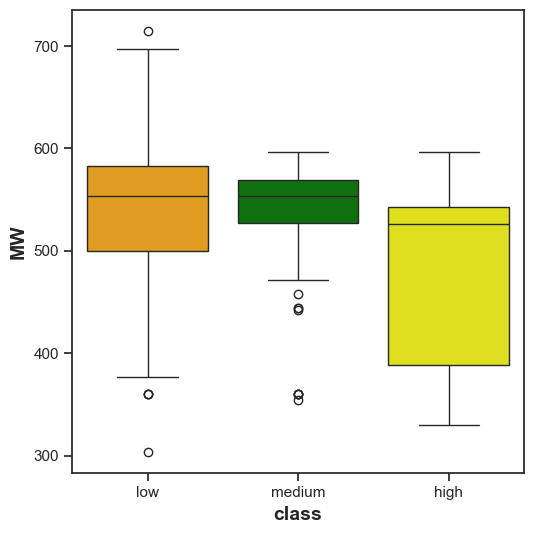

In [40]:

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_final, palette= ['orange', 'green', 'yellow'], hue='class')

plt.xlabel('class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_MW.pdf')


In [41]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,1992.0,0.000028,0.05,Different distribution (reject H0)


## LogP ## 

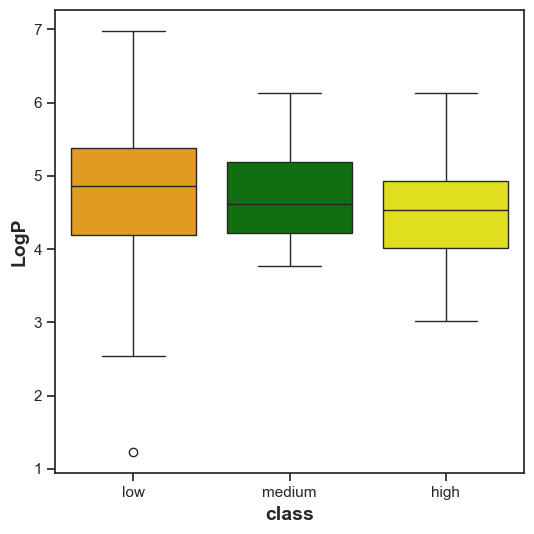

In [42]:
plt.figure(figsize= (5.5,5.5))

sns.boxplot(x= 'class', y= 'LogP', data= df_final, hue= 'class', palette= ['orange', 'green', 'yellow'])

plt.xlabel('class', fontsize= 14, fontweight= 'bold')
plt.ylabel('LogP', fontsize= 14, fontweight= 'bold')
plt.tight_layout()
plt.savefig('plot_LogP.pdf')

In [43]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,2415.0,0.005801,0.05,Different distribution (reject H0)


## NumHDonors ## 

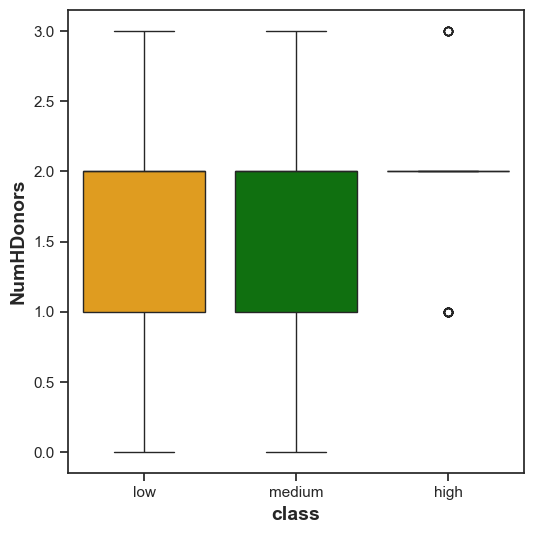

In [44]:
plt.figure(figsize= (5.5,5.5))

sns.boxplot(x= 'class', y= 'NumHDonors', data= df_final, hue= 'class', palette= ['orange', 'green', 'yellow'])

plt.xlabel('class', fontsize= 14, fontweight= 'bold')
plt.ylabel('NumHDonors', fontsize= 14, fontweight= 'bold')

plt.tight_layout()
plt.savefig('plot_NumHDonors.pdf')

In [45]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,3329.0,0.699088,0.05,Same distribution (fail to reject H0)


## NumHAcceptors ## 

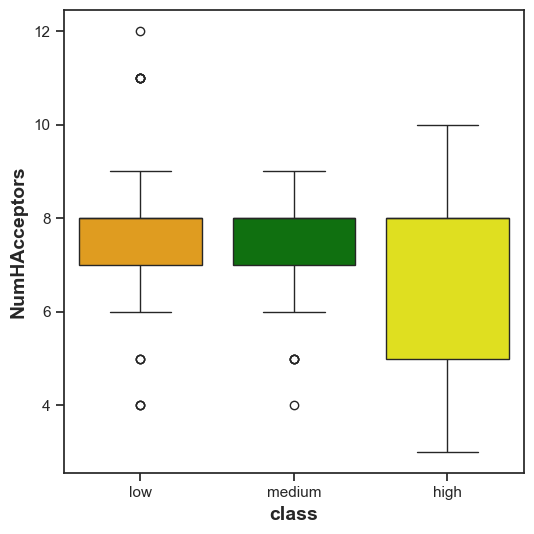

In [46]:
plt.figure(figsize= (5.5,5.5))

sns.boxplot(x= 'class', y= 'NumHAcceptors', data= df_final, hue= 'class', palette = ['orange', 'green', 'yellow'])

plt.xlabel('class', fontsize= 14, fontweight= 'bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight= 'bold')

plt.tight_layout()
plt.savefig('plot_NumHAcceptors.pdf')

In [47]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,2476.0,0.007052,0.05,Different distribution (reject H0)


## Data Interpretation ##

### Box Plots ###

#### pIC50 values #### 

The pIC50 descriptor exhibited a highly significant difference between the high and low classes, which is expected since the classes were generated directly from pIC50 values using quantile-based binning. In contrast, both MW and LogP also showed statistically significant differences despite not being used in the class definition. This suggests that molecular weight and lipophilicity are associated with bioactivity and may serve as important contributing descriptors in distinguishing compounds with varying levels of activity.

#### Lipinski's descriptors #### 

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors, and NumHAcceptors), only NumHDonors exhibited no difference between all the classes, while the other 3 descriptors (MW, LogP, and NumHAcceptors) show statistically significant differences.

### ZIP Files ###

In [48]:
! zip -r results.zip . -i *.csv *.pdf

updating: CleanData.csv (deflated 51%)
updating: plot_class.pdf (deflated 37%)
updating: bioactivity_data.csv (deflated 93%)
updating: EGFR Inhibitors.csv (deflated 76%)
updating: ChemBL data.csv (deflated 86%)
updating: plot_LogP.pdf (deflated 37%)
updating: bioactivity_preprocessed_data.csv (deflated 88%)
updating: plot_MW.pdf (deflated 40%)
updating: plot_NumHDonors.pdf (deflated 38%)
updating: plot_NumHAcceptors.pdf (deflated 38%)
updating: Clean_Data.csv (deflated 52%)
updating: plot_ic50.pdf (deflated 37%)
updating: top5_Binders.csv (deflated 26%)
updating: plot_MW_vs_LogP.pdf (deflated 13%)


## Regression Model ##

In [49]:
drop_cols = [
    'BindingDB Reactant_set_id',
    'Ligand SMILES',
    'bioactivity_class'
]

df_ml = df_final.drop(columns=drop_cols)

In [50]:
df_ml = df_ml[df_ml['class'] != 'medium']

In [51]:
df_ml

,MW,LogP,NumHDonors,NumHAcceptors,pIC50,class
0,499.619,4.50980,2,7,11.698970,high
1,350.219,5.28910,1,3,11.522879,high
2,388.265,4.93330,1,5,11.221849,high
3,344.216,3.59690,1,5,11.221849,high
4,344.216,3.59690,1,5,11.221849,high
...,...,...,...,...,...,...
244,695.603,5.51752,3,11,10.221849,low
245,694.619,5.44912,2,11,10.221849,low
246,529.693,3.09882,1,7,10.221849,low
247,696.635,5.69672,2,11,10.221849,low


### 1. Import libraries

In [52]:
from rdkit import Chem
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

mols = [Chem.MolFromSmiles(smi) for smi in df_final['Ligand SMILES']]

In [53]:
valid_idx = [i for i, mol in enumerate(mols) if mol is not None]

mols = [mols[i] for i in valid_idx]
df_valid = df_final.iloc[valid_idx].reset_index(drop=True)

In [54]:
np.product = np.prod

Mordred compatibility fix: np.product was deprecated in NumPy 1.25+

This line maps it back to np.prod to prevent Mordred from throwing an error.

## Molecular Descriptor Generation

Lipinski's 4 descriptors are useful for drug-likeness filtering but are 
too limited for building a predictive ML model. Here we use **Mordred**, 
a library that generates ~1,600 molecular descriptors covering 
topological, electronic, and structural properties of each compound.

Invalid SMILES strings are filtered out before descriptor calculation.

In [55]:
from mordred import Calculator, descriptors

calc = Calculator(descriptors, ignore_3D=True)

mordred_df = calc.pandas(mols)

100%|█████████████████████████████████████████| 240/240 [00:12<00:00, 19.71it/s]


In [56]:
df_ml = pd.concat([df_valid, mordred_df], axis=1)

In [57]:
df_ml = df_ml.select_dtypes(include=['number'])

In [58]:
df_ml = df_ml.dropna(axis=1)

In [59]:
df_ml

,BindingDB Reactant_set_id,MW,LogP,NumHDonors,NumHAcceptors,pIC50,nAcid,nBase,SpAbs_A,SpMax_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,51382967.0,499.619,4.50980,2,7,11.698970,0,1,47.488489,2.484083,...,10.503724,87.974766,499.269573,7.132422,4557,60,192.0,226.0,12.694444,8.277778
1,5347.0,350.219,5.28910,1,3,11.522879,0,0,29.423733,2.455860,...,10.099507,56.487008,349.021459,10.265337,1046,35,120.0,142.0,5.277778,4.750000
2,5318.0,388.265,4.93330,1,5,11.221849,0,0,30.892599,2.445084,...,10.045985,58.424931,387.058239,9.215672,1357,37,122.0,142.0,7.277778,5.500000
3,5366.0,344.216,3.59690,1,5,11.221849,0,0,26.963354,2.421019,...,9.946403,54.931982,343.043258,9.801236,930,32,110.0,128.0,6.527778,4.583333
4,5462.0,344.216,3.59690,1,5,11.221849,0,0,26.963354,2.421019,...,9.946403,54.931982,343.043258,9.801236,930,32,110.0,128.0,6.527778,4.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,51537952.0,695.603,5.51752,3,11,10.221849,0,1,57.475677,2.487125,...,11.000448,83.516128,694.214436,8.167229,8398,78,250.0,300.0,14.930556,9.597222
236,51468677.0,694.619,5.44912,2,11,10.221849,0,2,57.045806,2.486649,...,10.941660,83.376476,693.230420,8.060819,8438,78,248.0,297.0,14.840278,9.583333
237,1580206.0,529.693,3.09882,1,7,10.221849,0,3,50.924248,2.487450,...,10.613467,93.553951,529.327757,6.786253,4913,66,216.0,259.0,11.416667,8.305556
238,51537956.0,696.635,5.69672,2,11,10.221849,0,2,57.164795,2.486511,...,10.806470,82.963520,695.246070,7.900524,8446,77,240.0,283.0,15.729167,9.722222


In [60]:
X = df_ml.drop(columns='pIC50')
X

,BindingDB Reactant_set_id,MW,LogP,NumHDonors,NumHAcceptors,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,51382967.0,499.619,4.50980,2,7,0,1,47.488489,2.484083,4.909690,...,10.503724,87.974766,499.269573,7.132422,4557,60,192.0,226.0,12.694444,8.277778
1,5347.0,350.219,5.28910,1,3,0,0,29.423733,2.455860,4.911721,...,10.099507,56.487008,349.021459,10.265337,1046,35,120.0,142.0,5.277778,4.750000
2,5318.0,388.265,4.93330,1,5,0,0,30.892599,2.445084,4.890168,...,10.045985,58.424931,387.058239,9.215672,1357,37,122.0,142.0,7.277778,5.500000
3,5366.0,344.216,3.59690,1,5,0,0,26.963354,2.421019,4.842038,...,9.946403,54.931982,343.043258,9.801236,930,32,110.0,128.0,6.527778,4.583333
4,5462.0,344.216,3.59690,1,5,0,0,26.963354,2.421019,4.842038,...,9.946403,54.931982,343.043258,9.801236,930,32,110.0,128.0,6.527778,4.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,51537952.0,695.603,5.51752,3,11,0,1,57.475677,2.487125,4.974250,...,11.000448,83.516128,694.214436,8.167229,8398,78,250.0,300.0,14.930556,9.597222
236,51468677.0,694.619,5.44912,2,11,0,2,57.045806,2.486649,4.973297,...,10.941660,83.376476,693.230420,8.060819,8438,78,248.0,297.0,14.840278,9.583333
237,1580206.0,529.693,3.09882,1,7,0,3,50.924248,2.487450,4.851308,...,10.613467,93.553951,529.327757,6.786253,4913,66,216.0,259.0,11.416667,8.305556
238,51537956.0,696.635,5.69672,2,11,0,2,57.164795,2.486511,4.973022,...,10.806470,82.963520,695.246070,7.900524,8446,77,240.0,283.0,15.729167,9.722222


In [61]:
Y = df_ml.pIC50
Y

0      11.698970
1      11.522879
2      11.221849
3      11.221849
4      11.221849
         ...    
235    10.221849
236    10.221849
237    10.221849
238    10.221849
239    10.221849
Name: pIC50, Length: 240, dtype: float64

In [62]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0001)
X_reduced = selector.fit_transform(X)

In [63]:
X_reduced = pd.DataFrame(X_reduced)

In [64]:
X_reduced

,0,1,2,3,4,5,6,7,8,9,...,1179,1180,1181,1182,1183,1184,1185,1186,1187,1188
0,51382967.0,499.619,4.50980,2.0,7.0,1.0,47.488489,2.484083,4.909690,47.488489,...,10.503724,87.974766,499.269573,7.132422,4557.0,60.0,192.0,226.0,12.694444,8.277778
1,5347.0,350.219,5.28910,1.0,3.0,0.0,29.423733,2.455860,4.911721,29.423733,...,10.099507,56.487008,349.021459,10.265337,1046.0,35.0,120.0,142.0,5.277778,4.750000
2,5318.0,388.265,4.93330,1.0,5.0,0.0,30.892599,2.445084,4.890168,30.892599,...,10.045985,58.424931,387.058239,9.215672,1357.0,37.0,122.0,142.0,7.277778,5.500000
3,5366.0,344.216,3.59690,1.0,5.0,0.0,26.963354,2.421019,4.842038,26.963354,...,9.946403,54.931982,343.043258,9.801236,930.0,32.0,110.0,128.0,6.527778,4.583333
4,5462.0,344.216,3.59690,1.0,5.0,0.0,26.963354,2.421019,4.842038,26.963354,...,9.946403,54.931982,343.043258,9.801236,930.0,32.0,110.0,128.0,6.527778,4.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,51537952.0,695.603,5.51752,3.0,11.0,1.0,57.475677,2.487125,4.974250,57.475677,...,11.000448,83.516128,694.214436,8.167229,8398.0,78.0,250.0,300.0,14.930556,9.597222
236,51468677.0,694.619,5.44912,2.0,11.0,2.0,57.045806,2.486649,4.973297,57.045806,...,10.941660,83.376476,693.230420,8.060819,8438.0,78.0,248.0,297.0,14.840278,9.583333
237,1580206.0,529.693,3.09882,1.0,7.0,3.0,50.924248,2.487450,4.851308,50.924248,...,10.613467,93.553951,529.327757,6.786253,4913.0,66.0,216.0,259.0,11.416667,8.305556
238,51537956.0,696.635,5.69672,2.0,11.0,2.0,57.164795,2.486511,4.973022,57.164795,...,10.806470,82.963520,695.246070,7.900524,8446.0,77.0,240.0,283.0,15.729167,9.722222


## Random Forest Regression Model

We use a **Random Forest Regressor** to predict pIC50 as a continuous 
variable. Random Forest was chosen because:
- It handles high-dimensional descriptor data well
- It is robust to outliers
- It provides feature importance scores

The dataset is split 80/20 into training and test sets. 
VarianceThreshold is applied first to remove low-information features.

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X_reduced, Y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [66]:
X_train.shape, Y_train.shape

((192, 1189), (192,))

In [67]:
X_test.shape, Y_test.shape

((48, 1189), (48,))

In [68]:
model = RandomForestRegressor(n_estimators=100,random_state=42 )
model.fit(X_train, Y_train)
r2 = model.score(X_test, Y_test)
r2

0.6180456165667598

In [69]:
Y_pred = model.predict(X_test)
Y_pred

array([10.95209928, 11.22070324, 10.72858095, 10.6819285 , 10.69779537,
       10.65098115, 10.27285262, 10.8113755 , 11.10542939, 10.49619952,
       10.76730351, 10.5673982 , 10.66212279, 10.42331904, 10.72858095,
       10.65537949, 10.39782254, 10.90216833, 10.5921505 , 10.66200853,
       10.57869439, 10.88818585, 10.33306065, 10.92349223, 10.75503823,
       10.84789501, 11.10542939, 10.47733847, 10.66450733, 10.6986084 ,
       10.66727301, 10.33257407, 10.90479586, 10.4756225 , 10.93371339,
       10.91091907, 10.43235164, 11.0882624 , 10.73433818, 10.66249528,
       10.65537949, 10.73602063, 10.88370997, 10.75503823, 10.66159201,
       10.88818585, 10.6986084 , 10.8113755 ])

In [70]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

Y_pred = model.predict(X_test)

print("R² Score:", r2_score(Y_test, Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))

R² Score: 0.6180456165667598
MAE: 0.11474822385446626
RMSE: 0.17292681218908312


## Model Interpretation

An R² of ~0.60 indicates the model explains approximately 60% of the 
variance in pIC50 values. This is a reasonable baseline for a dataset 
of this size using 2D descriptors alone.

Potential improvements include:
- Using 3D conformer-based descriptors
- Applying SMOTE for class balancing
- Trying gradient boosting models (XGBoost, LightGBM)

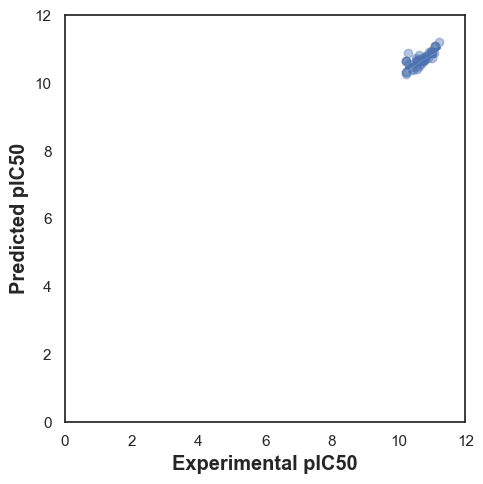

<Figure size 640x480 with 0 Axes>

In [71]:
sns.set(color_codes=True)
sns.set_style("white")

ax = sns.regplot(x=Y_test, y=Y_pred, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)

plt.tight_layout()
plt.show()   
plt.savefig('plot_Regression.png')

In [72]:
print("Before:", X.shape[1])
print("After:", X_reduced.shape[1])

Before: 1431
After: 1189


In [73]:
print(X_reduced.shape)  

(240, 1189)


In [74]:
from sklearn.model_selection import cross_val_score, train_test_split


importances = pd.Series(model.feature_importances_, index=X_reduced.columns)
top_features = importances.nlargest(50).index

X_top = X_reduced[top_features]
X_train_t, X_test_t, Y_train_t, Y_test_t = train_test_split(
    X_top, Y, test_size=0.2, random_state=42
)

model_tuned = RandomForestRegressor(n_estimators=200, max_depth=8,
                                     min_samples_split=5, random_state=42)
model_tuned.fit(X_train_t, Y_train_t)

print("R²:", r2_score(Y_test_t, model_tuned.predict(X_test_t)))
cv_scores = cross_val_score(model_tuned, X_top, Y, cv=5, scoring='r2')
print(f"Cross-validated R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

R²: 0.5677747486305584
Cross-validated R²: -18.576 ± 22.706


## Limitations & Future Work
The dataset contains 240 compounds after preprocessing, which is 
relatively small for the number of Mordred descriptors generated (1,189). 
This high feature-to-sample ratio limits model performance.

Future improvements:
- Expand dataset by including IC50 data from ChEMBL once API is restored
- Incorporate 3D conformer-based descriptors
- Test gradient boosting models (XGBoost, LightGBM)
- Apply SMOTE or other techniques to address data imbalance

## Model Performance Summary

| Metric | Value |
|--------|-------|
| R² Score | 0.618 |
| Cross-validated R² | 0.567 |
| MAE | 0.114 |
| RMSE | 0.172 |

**Dataset:** 240 compounds, EGFR target, BindingDB  
**Model:** Random Forest Regressor (200 trees, max_depth=8)  
**Features:** 1,189 Mordred descriptors (variance filtered)  
**Split:** 80% train / 20% test